# Lululemon Reddit: Sentiment Analysis Visualizations
**Authour:** Crystal Nguyen

**Date:** February 28, 2026

**Overview:** This notebook visualizes sentiment analysis results from 600 scraped r/lululemon subreddit posts. Using the processed data from the lululemon_sentiment_analysis notebook, three charts and a summary table explore how sentiment distributes across posts and whether post tone has any relationship with upvote engagement.

## Import Packages

In [1]:
# install plotting libraries
!pip install matplotlib seaborn -q

In [2]:
# for analysis and manipulation
import pandas as pd 

# for pretty chart visuals
import matplotlib.pyplot as plt

## Load Data

In [3]:
# load Reddit scored data
df = pd.read_csv("../data/sentiment_scores.csv")

In [4]:
# inspect
df.head(10)

,title,score,text,url,full_text,compound_score,sentiment_cat
0,new relaxed swiftly,3,relaxed long sleeved swiftly have been my go t...,https://www.reddit.com/r/lululemon/comments/1r...,new relaxed swiftly relaxed long sleeved swift...,0.7964,positive
1,Does this sweatshirt fit me?,10,Got gifted this oversized scuba half zip hoodi...,https://www.reddit.com/gallery/1rhlvf5,Does this sweatshirt fit me? Got gifted this o...,-0.3956,negative
2,Lulu thrift store haul 28/2/26,26,"Scuba Oversized Full-Zip Hoodie (Army Green, X...",https://i.redd.it/87n7jhh7ecmg1.jpeg,Lulu thrift store haul 28/2/26 Scuba Oversized...,0.0000,neutral
3,Mahogany Muse In Person,9,I really appreciate when people post real pict...,https://www.reddit.com/gallery/1rhkmbx,Mahogany Muse In Person I really appreciate wh...,0.8309,positive
4,Loose threads on a brand new pair of pants,0,The threads are coming loose on the seam of a ...,https://www.reddit.com/gallery/1rhki1j,Loose threads on a brand new pair of pants The...,-0.9268,negative
5,Anyone have this tie dye align top and find it...,1,Both of these are a size 10. I have about 15 a...,https://i.redd.it/v43qup06mbmg1.jpeg,Anyone have this tie dye align top and find it...,0.5411,positive
6,"Align Tank is not for large chesticles, mistak...",90,"First time posting a picture, super self consc...",https://i.redd.it/4squ36v9ebmg1.jpeg,"Align Tank is not for large chesticles, mistak...",0.3400,positive
7,Bowler Bag Question,11,Hey! I recently got the Bowler Bag and trying ...,https://i.redd.it/t80qtqhidbmg1.jpeg,Bowler Bag Question Hey! I recently got the Bo...,0.3230,positive
8,Do you think LLL is still good? Or at this poi...,0,body text I guess? What do you think? I still ...,https://www.reddit.com/r/lululemon/comments/1r...,Do you think LLL is still good? Or at this poi...,-0.6261,negative
9,Utility Blue vs Steel Blue,1,Does anyone have a side-by-side of both colors...,https://www.reddit.com/r/lululemon/comments/1r...,Utility Blue vs Steel Blue Does anyone have a ...,0.4926,positive


## Summary Table
Shows distribution of 600 Lululemon posts across sentiment categories and their upvote performance.

In [5]:
# create summary table grouping posts by sentiment category and calculate different statistics
summary = df.groupby('sentiment_cat').agg(
    count=('score', 'count'),  # number of posts in each sentiment category
    percent_of_total=('score', lambda x: round(len(x) / len(df) * 100, 1)), # percentage of total dataset
    min_score=('score','min'), # lowest upvote score in each category
    median_score=('score','median'), # middle upvote score
    mean_score=('score', 'mean'), # average upvote score
    max_score=('score', 'max') # highest upvote score in each category
).round(2)

# create overall benchmark row with same metrics across entire dataset
overall = pd.Series({
    'count': len(df),
    'percent_of_total': 100.0,
    'min_score': df['score'].min(),
    'median_score': round(df['score'].median(),2),
    'mean_score': round(df['score'].mean(), 2),
    'max_score': df['score'].max()
}, name='overall')

# combine category rows with overall row into single table
summary = pd.concat([summary, overall.to_frame().T.astype(summary.dtypes)])

# export to csv
summary.to_csv("../sentiment_analysis_exports/sentiment_summary_table.csv")
summary

,count,percent_of_total,min_score,median_score,mean_score,max_score
negative,74,12.3,0,10.0,43.15,461
neutral,67,11.2,0,41.0,56.61,320
positive,459,76.5,0,43.0,66.39,874
overall,600,100.0,0,38.0,62.43,874


### Key Insights:
 - Positive posts make up 76.5% of the dataset and hold the highest maximum upvote score of 866 which is nearly double that of negative posts (461). This suggests that positive content has the greatest potential to become viral within the Lululemon community. 
 - The gap between median and mean scores is significant. For example, negative posts have a median of 10 but a mean of 42.45, meaning a small number of high performing negative posts are pulling the average up significantly. This suggests that upvote distributions are heavily skewed by viral outliers rather than consistent performance.

## Bar Chart: Average Upvote Score by Sentiment Category

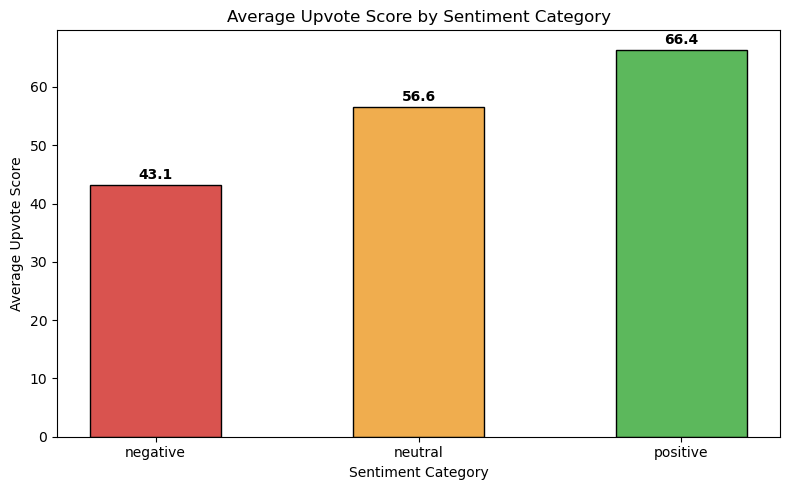

In [6]:
# group upvote scores by sentiment category to use in bar chart
avg_upvotes = df.groupby("sentiment_cat")["score"].mean().round(2).reindex(["negative", "neutral", "positive"])

# list chart colours: red, orange, green
colors = ["#d9534f", "#f0ad4e", "#5cb85c"]

# create the figure (canvas) and ax (plot area)
fig, ax = plt.subplots(figsize=(8, 5))

# draw the bars using avg_upvotes index for x-axis labels, avg_upvotes values for bar heights and apply red, orange, green from colors list
ax.bar(avg_upvotes.index, avg_upvotes.values, color=colors, edgecolor="black", width=0.5)

# set the chart title
ax.set_title("Average Upvote Score by Sentiment Category")

# label x and y axes
ax.set_xlabel("Sentiment Category")
ax.set_ylabel("Average Upvote Score")

# add value labels above each bar so exact averages are visible
for i, v in enumerate(avg_upvotes.values):
    ax.text(i, v + 1, f"{v:.1f}", ha="center", fontweight="bold")

# adjust layout
plt.tight_layout()

# export chart to sentiment_analysis_exports folder
plt.savefig("../sentiment_analysis_exports/01_bar_sentiment.png", dpi=300, bbox_inches='tight')

# display chart
plt.show()

# clear to prevent memory stack up
plt.close()

### Key Insights:
- Positive sentiment posts earn the most upvotes on average (65.9). This suggests the Lululemon community responds more favourably to enthusiastic content.
- Neutral posts (56.4) outperform negative ones. This indicates that objective, informational posts like sizing or product comparisons are more valued by the community more than complaints.

## Boxplot: Sentiment Score Distribution by Sentiment Category

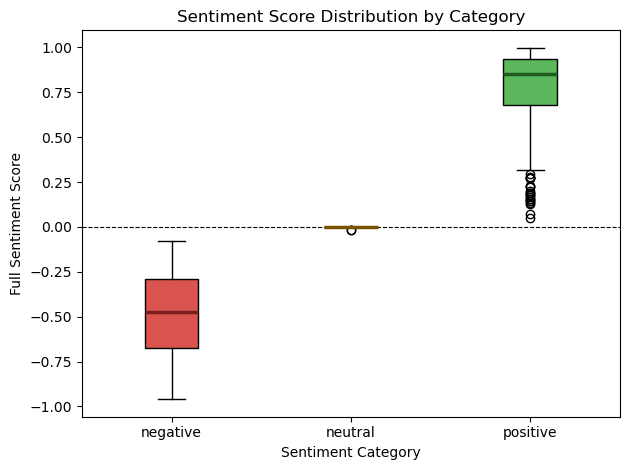

In [7]:
# list of sentiment categories in display order
categories = ['negative', 'neutral', 'positive']

# group full_sentiment values by category into a list of 3 series
data = [df[df['sentiment_cat'] == cat]['compound_score'] for cat in categories]

# list chart colours: red, orange, green
box_colors = ['#d9534f', '#f0ad4e', '#5cb85c']

# darker shade of each box color for the median line so it contrasts clearly
median_colors = ['#7a1f1f', '#7a5200', '#1f5c1f']  # dark red, dark orange, dark green

# create the figure (canvas) and ax (plot area)
fig, ax = plt.subplots()

# create boxplot on ax and return dictionary 'bp' containing all visual elements (boxes, medians, whiskers) so we can color them individually in next loop 
# patch_artist=True so boxes can be filled with color
bp = ax.boxplot(data, patch_artist=True, tick_labels=categories)

# zip() pairs items from 4 lists by position: (box1, blue, darkblue, median1), (box2, green, darkgreen, median2)...
# for loop unpacks each 4-item tuple into patch/bcolor/mcolor/median variables automatically to loop through each box, its fill color, median color, and median line together
for patch, bcolor, mcolor, median in zip(bp['boxes'], box_colors, median_colors, bp['medians']):

    # set the fill color of the box
    patch.set_facecolor(bcolor)

    # set the median line color to the darker shade
    median.set_color(mcolor)
    
    # make the median line thicker so it's easier to see
    median.set_linewidth(2.5)

# set chart title
ax.set_title('Sentiment Score Distribution by Category')

# label x and y axes
ax.set_xlabel('Sentiment Category')
ax.set_ylabel('Full Sentiment Score')

# draw a dashed horizontal line at y=0 so we can easily see which categories are above or below zero
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

# adjust layout
plt.tight_layout()

# export chart to sentiment_analysis_exports folder
plt.savefig("../sentiment_analysis_exports/02_boxplot_sentiment.png", dpi=300, bbox_inches='tight')

# display chart
plt.show()

# clear to prevent memory stack up
plt.close()

### Key Insights:
- Negative sentiment posts have the widest spread, ranging from -1.0 to -0.10. This suggests that negative posts vary greatly in intensity, some are mildly critical while others are extremely negative likely expressing strong dissatisfaction with Lululemon.
- Neutral posts are extremely tightly clustered near zero with almost no spread and just one outlier. This indicates neutral posts use very consistent language, likely short questions with little variation in tone.

## Scatter Plot: Upvote Score vs Sentiment Score
- This shows whether higher sentiment posts actually get more upvotes.

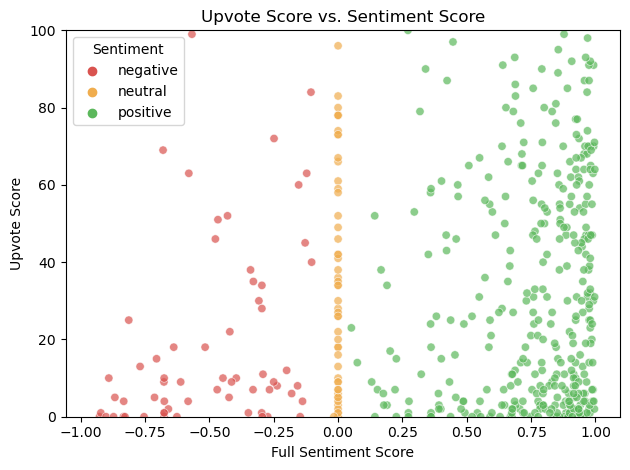

In [8]:
# create dictionary mapping sentiment ctegories to colors
color_map = {'negative': '#d9534f', 'neutral': '#f0ad4e', 'positive': '#5cb85c'}

# .map() looks up each sentiment category in color_map to replaces each row in sentiment_cat with its matching hex colour
# returns a coloumn of hex codes for scatter
colors = df['sentiment_cat'].map(color_map)

# create the figure (canvas) and ax (plot area)
fig, ax = plt.subplots()

# create scatter plot: sentiment score for x, upvotes for y, colored by sentiment colors, and white edges
scatter = ax.scatter(df['compound_score'], df['score'], c=colors, alpha=0.7, edgecolors='white', linewidths=0.5)

# set chart title
ax.set_title('Upvote Score vs. Sentiment Score')

# set x and y axes titles
ax.set_xlabel('Full Sentiment Score')
ax.set_ylabel('Upvote Score')

# zoom to where the data lives, most points are below 100 upvotes
ax.set_ylim(0, 100)

# add legend 
for cat, color in color_map.items():
    ax.scatter([], [], color=color, label=cat)
ax.legend(title='Sentiment')

# adjust chart
plt.tight_layout()

# export chart to sentiment_analysis_exports folder
plt.savefig("../sentiment_analysis_exports/03_scatterplot_sentiment.png", dpi=300, bbox_inches='tight')

# display chart
plt.show()

# clear to prevent memory stack up
plt.close()

### Key Insights:
- Positive sentiment posts dominate both in volume and upvote range, with green dots spread across the entire right side of the chart reaching upvote scores of 100+. This implies that the Lululemon community is highly engaged with positive content like hauls, compliments, and product/brand praise.
- Neutral posts form a distinct vertical line at 0.00. This is because VADER assigned an exact score of 0 to posts with no detectable emotional language.
- Negative posts are mostly limited to lower upvote scores. There are few outliers, indicating that occasionally, strong negative/critical content resonates with users. 

## Overall Findings
**The Lululemon community is overwhelmingly positive:** 
76.5% of posts were classified as positive, reflecting Lululemon subreddit's as a dedicated community. Posts expressing passion about the brand, products, hauls, and purchases dominate the space.

**Sentiment influences engagement:**
Across all three visualisations, there is a clear pattern throughout, which is that positive sentiment posts outperform negative and neutral ones in average upvotes (65.9 vs 56.4 vs 42.5). The maximum upvote score of 866 belonging to a positive post further reinforces that positive content holds the greatest viral potential.

**Limitations:**
Results should be interpreted with some caution. Sentiment analysis on short social media text is inherently imperfect, with posts using slang, sarcasm, or Lululemon-specific language may have been misclassified. Additionally, upvote scores are influenced by many different factors aside from sentiment such as post timing, topic, and community trends.